In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
clean = pd.read_csv("../data/processed/clean_sample.csv")
behavior = pd.read_csv("../data/processed/behavior_sample.csv")

## 1. Dataset Overview

We started with multi-GB CSVs from:
- **CICIDS2017** → Benign/Normal flows  
- **CICDDoS2019** → Various DDoS attack types  

We sampled ~10–15% due to size constraints, merged, cleaned, and engineered features.

Below are the high-level stats.

In [4]:
clean.head(), behavior.head()

(   Unnamed:_0  Flow_ID  Source_IP  Source_Port  Destination_IP  \
 0     62349.0      0.0        0.0      54800.0             0.0   
 1    754201.0      0.0        0.0      55013.0             0.0   
 2      8666.0      0.0        0.0      51003.0             0.0   
 3         0.0      0.0        0.0          0.0             0.0   
 4    793901.0      0.0        0.0      50055.0             0.0   
 
    Destination_Port  Protocol  Timestamp  Flow_Duration  Total_Fwd_Packets  \
 0             41918      17.0        0.0              2                  2   
 1             22315       6.0        0.0              1                  2   
 2             18041      17.0        0.0         213357                  6   
 3                53       0.0        0.0            161                  2   
 4             55762       6.0        0.0              1                  2   
 
    ...  Active_Max  Active_Min  Idle_Mean  Idle_Std  Idle_Max  Idle_Min  \
 0  ...         0.0         0.0        0.0  

## 1. Dataset Overview

We worked with two major cybersecurity datasets:

- **CICIDS2017** — Normal (benign) traffic  
- **CICDDoS2019** — Multiple DDoS attack types  

Both datasets originally contained **millions of rows**, so we performed safe sampling to allow exploratory analysis on local hardware.

This notebook demonstrates how the dataset transformed across:
1. Raw Data  
2. Cleaning & Preprocessing  
3. Behavior-Based Feature Engineering  

In [5]:
print("Clean sample shape:", clean.shape)
print("Behavior sample shape:", behavior.shape)

Clean sample shape: (5000, 89)
Behavior sample shape: (5000, 95)


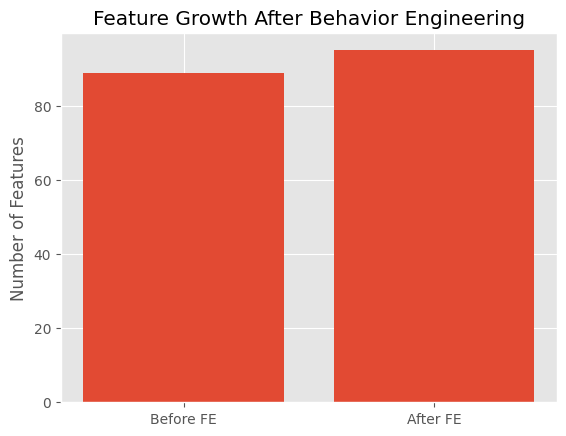

In [6]:
plt.bar(["Before FE", "After FE"], [len(clean.columns), len(behavior.columns)])
plt.title("Feature Growth After Behavior Engineering")
plt.ylabel("Number of Features")
plt.show()

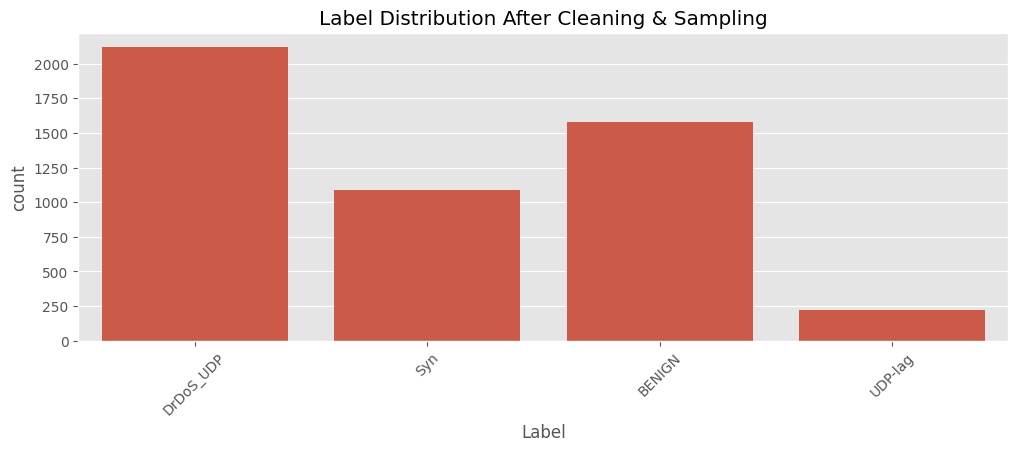

In [7]:
plt.figure(figsize=(12,4))
sns.countplot(x=behavior["Label"])
plt.title("Label Distribution After Cleaning & Sampling")
plt.xticks(rotation=45)
plt.show()

## 2. Feature Correlation Analysis

Correlation reveals which features strongly influence DDoS behavior.

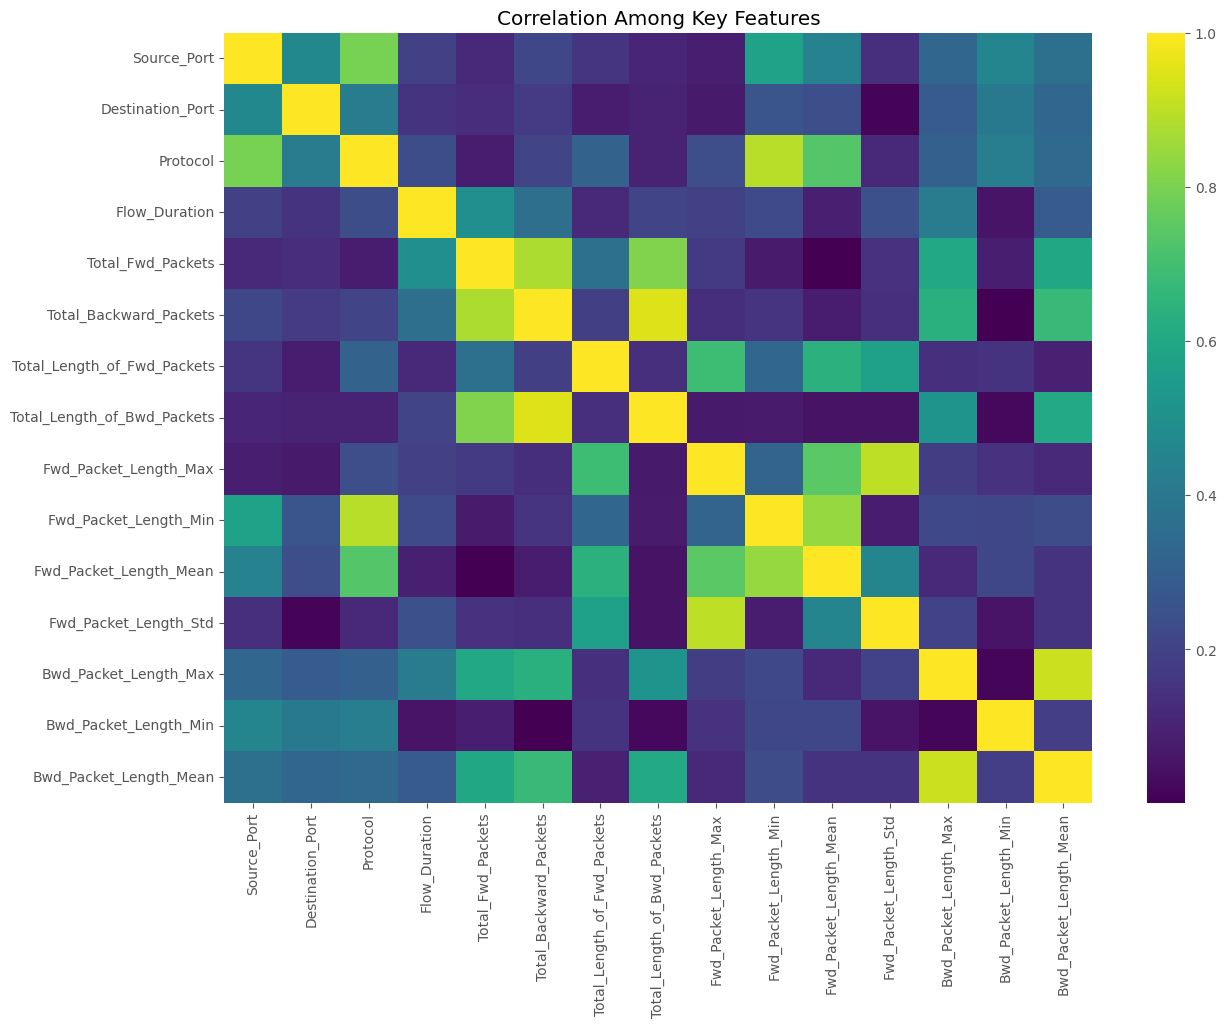

In [9]:
plt.figure(figsize=(14,10))
subset = behavior.select_dtypes(include=["float64", "int64"]).iloc[:, :15]
sns.heatmap(subset.corr().abs(), cmap="viridis")
plt.title("Correlation Among Key Features")
plt.show()

## 3. Behavior-Based Feature Engineering

We added **12 high-impact behavioral features** designed specifically for DDoS detection:

- `packet_rate`
- `byte_rate`
- `burstiness`
- `flow_size`
- `avg_payload_size`
- `fwd_bwd_ratio`
- `iat_mean_combined`
- `total_flags`
- `flag_intensity`
- `syn_dominance`
- `packet_energy`

These convert raw flow data into **attack behavioral signatures**, allowing ML models to detect patterns even when attackers change payload or destination.

In [10]:
added_features = set(behavior.columns) - set(clean.columns)
added_features

{'avg_payload_size',
 'burstiness',
 'byte_rate',
 'flag_intensity',
 'flow_size',
 'fwd_bwd_ratio',
 'iat_mean_combined',
 'packet_energy',
 'packet_rate',
 'packet_size_var',
 'syn_dominance',
 'total_flags'}

In [ ]:
cols = ["packet_rate", "byte_rate", "flow_size", "syn_dominance"]

plt.figure(figsize=(14,8))
for i, c in enumerate(cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(behavior[c], kde=True)
    plt.title(c)

plt.tight_layout()
plt.show()

In [ ]:
sns.pairplot(
    behavior[["packet_rate", "byte_rate", "burstiness", "flow_size", "Label"]],
    hue="Label",
    corner=True
)
plt.show()